In [1]:
import xarray as xr
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os
from matplotlib.lines import Line2D

from shapely.geometry import Point, Polygon as ShapelyPolygon
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
import matplotlib.ticker as ticker

import seaborn as sns
from shapely.geometry import Point, Polygon as ShapelyPolygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import imageio

import cmocean
import cmocean.cm as cmo
import importlib
import utils  # Importing the utils module


import matplotlib.patheffects as path_effects
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

from matplotlib.colors import LinearSegmentedColormap

In [2]:
# File Paths to data

repo_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/'
output_path = repo_path + 'processed_data/'
fig_path = repo_path + 'figures/'

#Files
start_file = 'IDLloc_spawning_21dfilter.csv'

starting_location_df=pd.read_csv(output_path + start_file) 

In [3]:
# List of simulations and locations
locations = ['BS', 'GERL', 'GP', 'MB2']

file = output_path + 'processed_trajectories_21dfilter.csv'

processed_df=pd.read_csv(file) 
print('raw number of larvae:', processed_df.larval_id.nunique())
df = processed_df.copy()

raw number of larvae: 11487


In [4]:
# Import Utils for consistent naming, colors, labling, and mapping
importlib.reload(utils) # Run this if you update something in your utils file you need

# Import necessary data and functions from utils
hypotheses = utils.hypotheses
stages = utils.stages
locations = utils.locations
start_years = utils.start_years
months_data = utils.months_data
extents = utils.extents
bathymetry = utils.bathymetry

# function
plot_region = utils.plot_region
plot_contour = utils.plot_contour

importlib.reload(utils) # Run this if you update something in your utils file you need

boxes = {key: value['boxes'] for key, value in locations.items()}
location_labels = {key: value['name'] for key, value in locations.items()}
location_colors = {key: value['color'] for key, value in locations.items()}
location_order = {key: value['order'] for key, value in locations.items()}

# Different Hypotheses (in this case only hi res)
hypotheses = utils.hypotheses
hypotheses_name = {key: value['name'] for key, value in hypotheses.items()}
hypothesis_labels = {key: value['label'] for key, value in hypotheses.items()}
hypothesis_order = {key: value['order'] for key, value in hypotheses.items()}

start_years = utils.start_years
sy_labels = {key: value['label'] for key, value in start_years.items()}
sy_marker = {key: value['marker'] for key, value in start_years.items()}

extent = [-76, -46, -71, -58]

# Helper function to plot the base map and specific nursery box
def plot_nurseries_individ(ax, extent, locations, nursery=None, box_zorder=6):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    # If a specific nursery is provided, plot only that nursery
    if nursery in locations:
        loc_data = locations[nursery]
        for box in loc_data['boxes']:
            lonpoly = box['lonpoly']
            latpoly = box['latpoly']
            poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor='k', zorder=box_zorder, transform=ccrs.PlateCarree())
            ax.add_patch(poly)
    else:
        print(f"Nursery '{nursery}' not found in locations.")

print(extent)

[-76, -46, -71, -58]


# Process Data:
### starting_location_df ➜ filter by hypothesis, nursery, year ➜ bin release locations ➜ build heatmaps ➜ normalize ➜ analyze concentration

In [5]:
def preprocess_spawning_data(df, lat_bins, lon_bins):
    """
    Create a heatmap of release locations from a pre-filtered DataFrame.
    Assumes df already contains only the relevant hypothesis and years.
    """
    # Initialize a heatmap grid
    heatmap = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))

    # Get indices for latitude and longitude bins
    lat_indices = np.digitize(df['release_lat'], lat_bins) - 1
    lon_indices = np.digitize(df['release_lon'], lon_bins) - 1

    # Filter out points outside grid bounds
    valid_points = (lat_indices >= 0) & (lat_indices < len(lat_bins) - 1) & \
                   (lon_indices >= 0) & (lon_indices < len(lon_bins) - 1)
    lat_indices = lat_indices[valid_points]
    lon_indices = lon_indices[valid_points]

    # Populate the heatmap
    np.add.at(heatmap, (lat_indices, lon_indices), 1)

    return heatmap

In [6]:
# Define spatial extent
lat_min, lat_max = -75, -50
lon_min, lon_max = 265, 330  # Using 0–360 system

# Define grid resolution
lat_resolution, lon_resolution = 0.25, 0.50  # degrees

# Generate latitude and longitude bins
lat_bins = np.arange(lat_min, lat_max + lat_resolution, lat_resolution)
lon_bins = np.arange(lon_min, lon_max + lon_resolution, lon_resolution)

In [7]:
def compute_spawning_heatmaps(df, nurseries, hypothesis, years, lat_bins, lon_bins):
    """
    Compute raw and normalized 2D heatmaps of spawning origins per nursery.

    Returns:
        raw_heatmaps (dict): {nursery: 2D np.array of counts}
        normalized_heatmaps (dict): {nursery: 2D np.array summing to 1}
    """
    raw_heatmaps = {}
    normalized_heatmaps = {}

    for nursery in nurseries:
        subset = df[
            (df['hypothesis'] == hypothesis) &
            (df['IDL_loc'] == nursery) &
            (df['start_year'].isin(years))
        ].copy()

        if subset.empty:
            print(f"⚠️ No spawning data for {nursery}")
            continue

        subset['release_lon'] = subset['release_lon'] % 360
        heatmap = preprocess_spawning_data(subset, lat_bins, lon_bins)

        raw_heatmaps[nursery] = heatmap
        normalized_heatmaps[nursery] = heatmap / heatmap.sum() if heatmap.sum() > 0 else heatmap

    return raw_heatmaps, normalized_heatmaps

# Compute Data

In [8]:
nurseries = ['BS', 'GERL', 'GP', 'MB2']
hypothesis = 'h_dvm'
years = [2016, 2017, 2018]

raw_hm, norm_hm = compute_spawning_heatmaps(
    df=starting_location_df,
    nurseries=nurseries,
    hypothesis=hypothesis,
    years=years,
    lat_bins=lat_bins,
    lon_bins=lon_bins
)

In [9]:
def compute_concentration_metrics(normalized_heatmaps, top_n=5):
    """
    Compute concentration metrics for normalized spawning heatmaps.

    Returns:
        pd.DataFrame with one row per nursery and metrics:
        - max_bin
        - top_n_sum
        - entropy
        - nonzero_bins
    """
    rows = []
    for nursery, h in normalized_heatmaps.items():
        nz = h[h > 0]
        max_bin = nz.max()
        top_n_sum = np.sort(nz.flatten())[-top_n:].sum()
        entropy = -np.sum(nz * np.log(nz))
        rows.append({
            'nursery': nursery,
            'max_bin': round(max_bin, 4),
            f'top_{top_n}_sum': round(top_n_sum, 4),
            'entropy': round(entropy, 3),
            'nonzero_bins': len(nz)
        })
    return pd.DataFrame(rows)

In [10]:
for nursery in nurseries:
    raw = raw_hm[nursery]
    norm = norm_hm[nursery]

    print(f"Nursery: {nursery}")
    print(f"  Raw total: {raw.sum()}")
    print(f"  Normalized total: {norm.sum()}")  # Should be ~1.0
    print(f"  Max raw bin: {raw.max()}, max norm bin: {norm.max():.4f}")
    print(f"  Raw bin [10,10]: {raw[10,10]}, Norm bin [10,10]: {norm[10,10]:.4f}")
    print()

Nursery: BS
  Raw total: 711.0
  Normalized total: 1.0
  Max raw bin: 56.0, max norm bin: 0.0788
  Raw bin [10,10]: 0.0, Norm bin [10,10]: 0.0000

Nursery: GERL
  Raw total: 106.0
  Normalized total: 1.0000000000000002
  Max raw bin: 7.0, max norm bin: 0.0660
  Raw bin [10,10]: 0.0, Norm bin [10,10]: 0.0000

Nursery: GP
  Raw total: 116.0
  Normalized total: 0.9999999999999999
  Max raw bin: 7.0, max norm bin: 0.0603
  Raw bin [10,10]: 0.0, Norm bin [10,10]: 0.0000

Nursery: MB2
  Raw total: 167.0
  Normalized total: 0.9999999999999999
  Max raw bin: 31.0, max norm bin: 0.1856
  Raw bin [10,10]: 0.0, Norm bin [10,10]: 0.0000



In [15]:
concentration_df = compute_concentration_metrics(norm_hm, top_n=5)
concentration_df

,nursery,max_bin,top_5_sum,entropy,nonzero_bins
0,BS,0.0788,0.2588,4.003,124
1,GERL,0.0660,0.3019,3.508,44
2,GP,0.0603,0.2328,3.953,64
3,MB2,0.1856,0.5509,3.037,41


In [11]:
def summarize_normalized_heatmaps(normalized_heatmaps, raw_heatmaps, hypothesis):
    """
    Summarize spawning origin heatmaps with concentration metrics and embryo size.

    Parameters:
        normalized_heatmaps (dict): Normalized 2D histograms by nursery.
        raw_heatmaps (dict): Raw 2D histograms by nursery.
        hypothesis (str): Name of the behavioral hypothesis ('h_dvm' or 'h_size').

    Returns:
        pd.DataFrame with summary statistics per nursery.
    """
    embryo_size = 620 if hypothesis == 'h_dvm' else 640

    rows = []
    for nursery, h in normalized_heatmaps.items():
        raw = raw_heatmaps[nursery]
        nz = h[h > 0]
        rows.append({
            'embryo_size': embryo_size,
            'nursery': nursery,
            'total_particles': int(raw.sum()),
            'max_bin': round(nz.max(), 4),
            'top_5_sum': round(np.sort(nz.flatten())[-5:].sum(), 4),
            'entropy': round(-np.sum(nz * np.log(nz)), 3),
            'nonzero_bins': len(nz)
        })
    return pd.DataFrame(rows)

In [12]:
summary_df = summarize_normalized_heatmaps(norm_hm, raw_hm, hypothesis)
display(summary_df)

,embryo_size,nursery,total_particles,max_bin,top_5_sum,entropy,nonzero_bins
0,620,BS,711,0.0788,0.2588,4.003,124
1,620,GERL,106,0.0660,0.3019,3.508,44
2,620,GP,116,0.0603,0.2328,3.953,64
3,620,MB2,167,0.1856,0.5509,3.037,41


## Plot

In [13]:
# Define your custom colormap
perry_colors = ['#2892c6', '#6da9b3', '#9fc29a',
                '#cfde81', '#fafa64', '#fcc44d',
                '#fa8c33', '#f25822', '#e70f15']
perry_cmap = LinearSegmentedColormap.from_list("perry_colors", perry_colors)


In [14]:
def plot_normalized_spawning_grid_from_heatmaps(
    heatmap_dict, nurseries, extent, lat_bins, lon_bins, vmax,
    hypothesis=None, years=None, save_path=None
):
    """
    Plot a 2x2 grid of normalized spawning heatmaps from precomputed data.
    """
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import numpy as np

    fig, axs = plt.subplots(2, 2, figsize=(10, 10),
                            subplot_kw={'projection': ccrs.SouthPolarStereo(central_longitude=-65)},
                            constrained_layout=True)

    axs = axs.flatten()
    vmin = 0

    for ax, nursery in zip(axs, nurseries):
        data = heatmap_dict.get(nursery, None)
        if data is None:
            ax.text(0.5, 0.5, f'No data for {nursery}', transform=ax.transAxes,
                    ha='center', va='center', fontsize=12, color='gray')
            continue

        plot_region(ax, extent)
        plot_nurseries_individ(ax, extent, locations, nursery)
        plot_contour(ax, extent)

        norm_heatmap = data['normalized']
        total_particles = data['total_particles']
        masked = np.ma.masked_where(norm_heatmap <= 0, norm_heatmap)

        lon_mid = (lon_bins[:-1] + lon_bins[1:]) / 2
        lat_mid = (lat_bins[:-1] + lat_bins[1:]) / 2
        mesh = ax.pcolormesh(lon_mid, lat_mid, masked,
                             cmap=perry_cmap, transform=ccrs.PlateCarree(),
                             vmin=vmin, vmax=vmax)

        # Panel label
        label = chr(65 + axs.tolist().index(ax))
        ax.text(0.02, 0.98, label, transform=ax.transAxes,
                fontsize=14, fontweight='bold', va='top', ha='left')

        # # Total particle annotation
        # ax.text(0.98, 0.02, f"n = {total_particles}", transform=ax.transAxes,
        #         fontsize=11, va='bottom', ha='right',
        #         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2'))

    # Colorbar
    cbar = fig.colorbar(mesh, ax=axs, location='right', shrink=0.8, pad=0.05)
    cbar.set_label('Fraction of Release Locations', fontsize=12)

    title_str = "Proportional Spawning Origins (Normalized)"
    if hypothesis and years:
        title_str += f"\nHypothesis: {hypothesis}, Years: {years[0]}–{years[-1]}"
    fig.suptitle(title_str, fontsize=14)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Normalized spawning summary grid saved to {save_path}")
    plt.show()

✅ Normalized spawning summary grid saved to figures/spawning_summary_grid_normalized_h_dvm.png


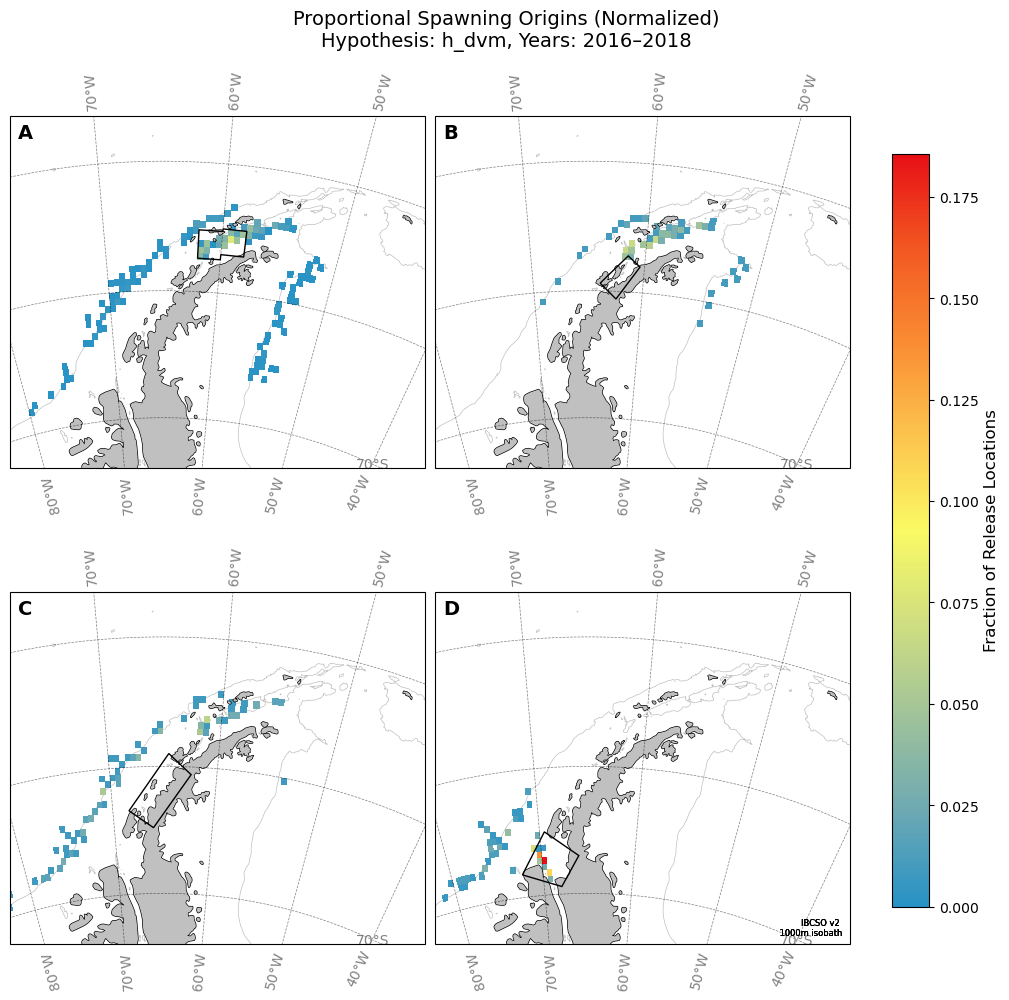

,embryo_size,nursery,total_particles,max_bin,top_5_sum,entropy,nonzero_bins
0,620,BS,711,0.0788,0.2588,4.003,124
1,620,GERL,106,0.0660,0.3019,3.508,44
2,620,GP,116,0.0603,0.2328,3.953,64
3,620,MB2,167,0.1856,0.5509,3.037,41


In [44]:
# Setup
nurseries = ['BS', 'GERL', 'GP', 'MB2']
hypothesis = 'h_dvm'
years = [2016, 2017, 2018]
extent = [-76, -46, -71, -58]
save_path =f'figures/spawning_summary_grid_normalized_{hypothesis}.png'

# Step 1: Analyze with your actual function
raw_hm, norm_hm = compute_spawning_heatmaps(
    df=starting_location_df,
    nurseries=nurseries,
    hypothesis=hypothesis,
    years=years,
    lat_bins=lat_bins,
    lon_bins=lon_bins
)

# Step 2: Wrap into the dict format expected by the plot function
heatmap_dict = {}
vmax = 0  # initialize to find global max
for nursery in nurseries:
    norm = norm_hm.get(nursery, None)
    if norm is not None:
        raw = raw_hm[nursery]
        heatmap_dict[nursery] = {
            'normalized': norm,
            'total_particles': int(raw.sum())
        }
        vmax = max(vmax, norm.max())  # update global max

# Step 3: Plot
plot_normalized_spawning_grid_from_heatmaps(
    heatmap_dict=heatmap_dict,
    nurseries=nurseries,
    extent=extent,
    lat_bins=lat_bins,
    lon_bins=lon_bins,
    vmax=vmax,
    hypothesis=hypothesis,
    years=years,
    save_path=save_path
)

# ✅ Step 4: Get summary DataFrame
summary_df = summarize_normalized_heatmaps(
    normalized_heatmaps=norm_hm,
    raw_heatmaps=raw_hm,
    hypothesis=hypothesis
)

summary_df

✅ Normalized spawning summary grid saved to figures/spawning_summary_grid_normalized_h_size.png


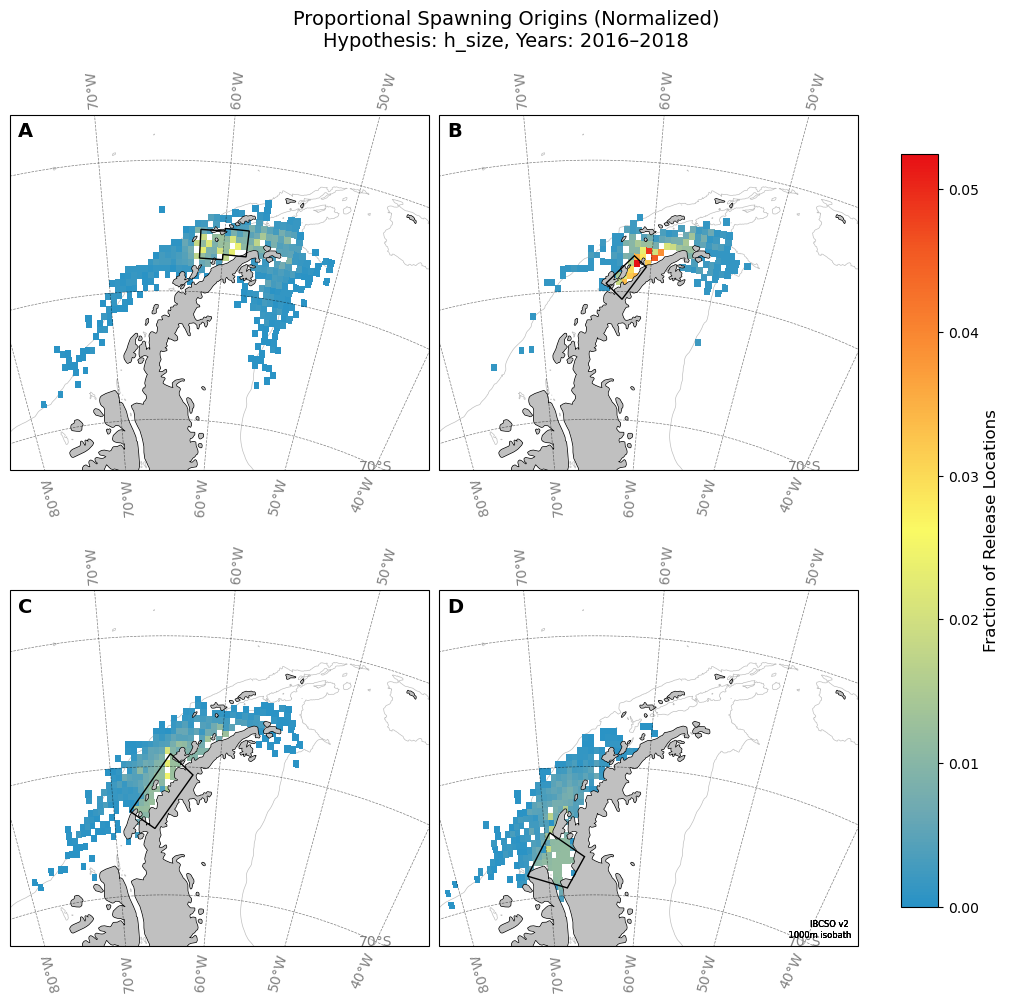

,embryo_size,nursery,total_particles,max_bin,top_5_sum,entropy,nonzero_bins
0,640,BS,2500,0.0236,0.1120,5.111,316
1,640,GERL,897,0.0524,0.2207,4.230,144
2,640,GP,2686,0.0246,0.0975,5.009,256
3,640,MB2,2879,0.0188,0.0806,5.089,251


In [45]:
 
# Setup
nurseries = ['BS', 'GERL', 'GP', 'MB2']
hypothesis = 'h_size'
years = [2016, 2017, 2018]
extent = [-76, -46, -71, -58]
save_path =f'figures/spawning_summary_grid_normalized_{hypothesis}.png'

# Step 1: Analyze with your actual function
raw_hm, norm_hm = compute_spawning_heatmaps(
    df=starting_location_df,
    nurseries=nurseries,
    hypothesis=hypothesis,
    years=years,
    lat_bins=lat_bins,
    lon_bins=lon_bins
)

# Step 2: Wrap into the dict format expected by the plot function
heatmap_dict = {}
vmax = 0  # initialize to find global max
for nursery in nurseries:
    norm = norm_hm.get(nursery, None)
    if norm is not None:
        raw = raw_hm[nursery]
        heatmap_dict[nursery] = {
            'normalized': norm,
            'total_particles': int(raw.sum())
        }
        vmax = max(vmax, norm.max())  # update global max

# Step 3: Plot
plot_normalized_spawning_grid_from_heatmaps(
    heatmap_dict=heatmap_dict,
    nurseries=nurseries,
    extent=extent,
    lat_bins=lat_bins,
    lon_bins=lon_bins,
    vmax=vmax,
    hypothesis=hypothesis,
    years=years,
    save_path=save_path
)

# ✅ Step 4: Get summary DataFrame
summary_df = summarize_normalized_heatmaps(
    normalized_heatmaps=norm_hm,
    raw_heatmaps=raw_hm,
    hypothesis=hypothesis
)

summary_df

In [43]:
# ✅ Step 4: Get summary DataFrame
summary_df = summarize_normalized_heatmaps(
    normalized_heatmaps=norm_hm,
    raw_heatmaps=raw_hm,
    hypothesis=hypothesis
)

summary_df

,embryo_size,nursery,total_particles,max_bin,top_5_sum,entropy,nonzero_bins
0,640,BS,2500,0.0236,0.1120,5.111,316
1,640,GERL,897,0.0524,0.2207,4.230,144
2,640,GP,2686,0.0246,0.0975,5.009,256
3,640,MB2,2879,0.0188,0.0806,5.089,251


# Repeat Using Percents

In [21]:
def plot_percent_spawning_grid(
    heatmap_dict, nurseries, extent, lat_bins, lon_bins, vmax,
    hypothesis=None, years=None, save_path=None
):
    """
    Plot a 2x2 grid of spawning origin heatmaps from precomputed, *normalized* data,
    displayed as PERCENT of origins (0–100).

    Parameters
    ----------
    heatmap_dict : dict
        {nursery: {'normalized': 2D array in [0,1], 'total_particles': int}}
    nurseries : list[str]
    extent : [lon_min, lon_max, lat_min, lat_max]
    lat_bins, lon_bins : 1D arrays of bin edges
    vmax : float
        Max of normalized values (0–1). Will be displayed as vmax*100 on the colorbar.
    hypothesis : str | None
    years : list[int] | None
    save_path : str | None
    """
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import numpy as np

    fig, axs = plt.subplots(
        2, 2, figsize=(10, 10),
        subplot_kw={'projection': ccrs.SouthPolarStereo(central_longitude=-65)},
        constrained_layout=True
    )
    axs = axs.flatten()

    # Midpoints for pcolormesh
    lon_mid = (lon_bins[:-1] + lon_bins[1:]) / 2
    lat_mid = (lat_bins[:-1] + lat_bins[1:]) / 2

    vmin_display = 0.0
    vmax_display = (vmax or 0.0) * 100.0  # convert fraction->percent for the color scale

    mesh = None
    for i, (ax, nursery) in enumerate(zip(axs, nurseries)):
        data_entry = heatmap_dict.get(nursery, None)
        if data_entry is None:
            ax.text(0.5, 0.5, f'No data for {nursery}', transform=ax.transAxes,
                    ha='center', va='center', fontsize=12, color='gray')
            continue

        # Base layers
        plot_region(ax, extent)
        plot_nurseries_individ(ax, extent, locations, nursery)
        plot_contour(ax, extent)

        # Convert normalized (0–1) -> percent (0–100)
        norm_heatmap = data_entry['normalized']
        percent_heatmap = norm_heatmap * 100.0
        masked = np.ma.masked_where(percent_heatmap <= 0, percent_heatmap)

        mesh = ax.pcolormesh(
            lon_mid, lat_mid, masked,
            cmap=perry_cmap, transform=ccrs.PlateCarree(),
            vmin=0, vmax=18, shading='auto'
        )

        # Panel label
        ax.text(0.02, 0.98, chr(65 + i), transform=ax.transAxes,
                fontsize=14, fontweight='bold', va='top', ha='left')

    # Colorbar (only if at least one mesh was drawn)
    if mesh is not None:
        cbar = fig.colorbar(mesh, ax=axs, location='right', shrink=0.8, pad=0.05)
        cbar.set_label('% of nursery’s total retained larvae', fontsize=12)

    # Title
    title_str = "Spawning Origin Maps (expressed as % of contributing releases)"
    if hypothesis and years:
        title_str += f"\nHypothesis: {hypothesis}, Years: {years[0]}–{years[-1]}"
    fig.suptitle(title_str, fontsize=14)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Spawning summary grid saved to {save_path}")
    plt.show()

✅ Spawning summary grid saved to figures/spawning_summary_grid_normalized_h_dvm_percent.pdf


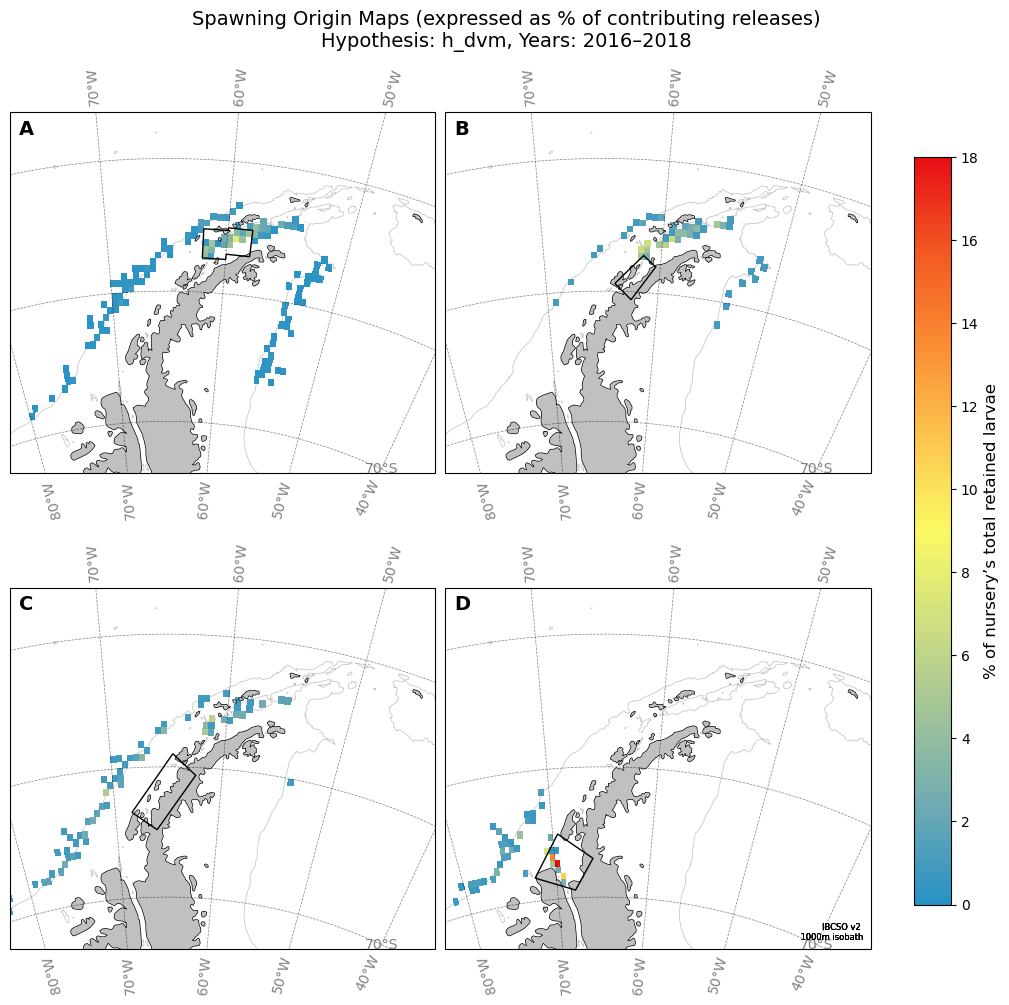

,embryo_size,nursery,total_particles,max_bin,top_5_sum,entropy,nonzero_bins
0,620,BS,711,0.0788,0.2588,4.003,124
1,620,GERL,106,0.0660,0.3019,3.508,44
2,620,GP,116,0.0603,0.2328,3.953,64
3,620,MB2,167,0.1856,0.5509,3.037,41


In [24]:
# Setup
nurseries = ['BS', 'GERL', 'GP', 'MB2']
hypothesis = 'h_dvm'
years = [2016, 2017, 2018]
extent = [-76, -46, -71, -58]
save_path =f'figures/spawning_summary_grid_normalized_{hypothesis}_percent.pdf'

# Step 1: Analyze with your actual function
raw_hm, norm_hm = compute_spawning_heatmaps(
    df=starting_location_df,
    nurseries=nurseries,
    hypothesis=hypothesis,
    years=years,
    lat_bins=lat_bins,
    lon_bins=lon_bins
)

# Step 2: Wrap into the dict format expected by the plot function
heatmap_dict = {}
vmax = 0  # initialize to find global max
for nursery in nurseries:
    norm = norm_hm.get(nursery, None)
    if norm is not None:
        raw = raw_hm[nursery]
        heatmap_dict[nursery] = {
            'normalized': norm,
            'total_particles': int(raw.sum())
        }
        vmax = max(vmax, norm.max())  # update global max

# Step 3: Plot
plot_percent_spawning_grid(
    heatmap_dict=heatmap_dict,
    nurseries=nurseries,
    extent=extent,
    lat_bins=lat_bins,
    lon_bins=lon_bins,
    vmax=vmax,
    hypothesis=hypothesis,
    years=years,
    save_path=save_path
)

# ✅ Step 4: Get summary DataFrame
summary_df = summarize_normalized_heatmaps(
    normalized_heatmaps=norm_hm,
    raw_heatmaps=raw_hm,
    hypothesis=hypothesis
)

summary_df

✅ Spawning summary grid saved to figures/spawning_summary_grid_normalized_h_size_percent.pdf


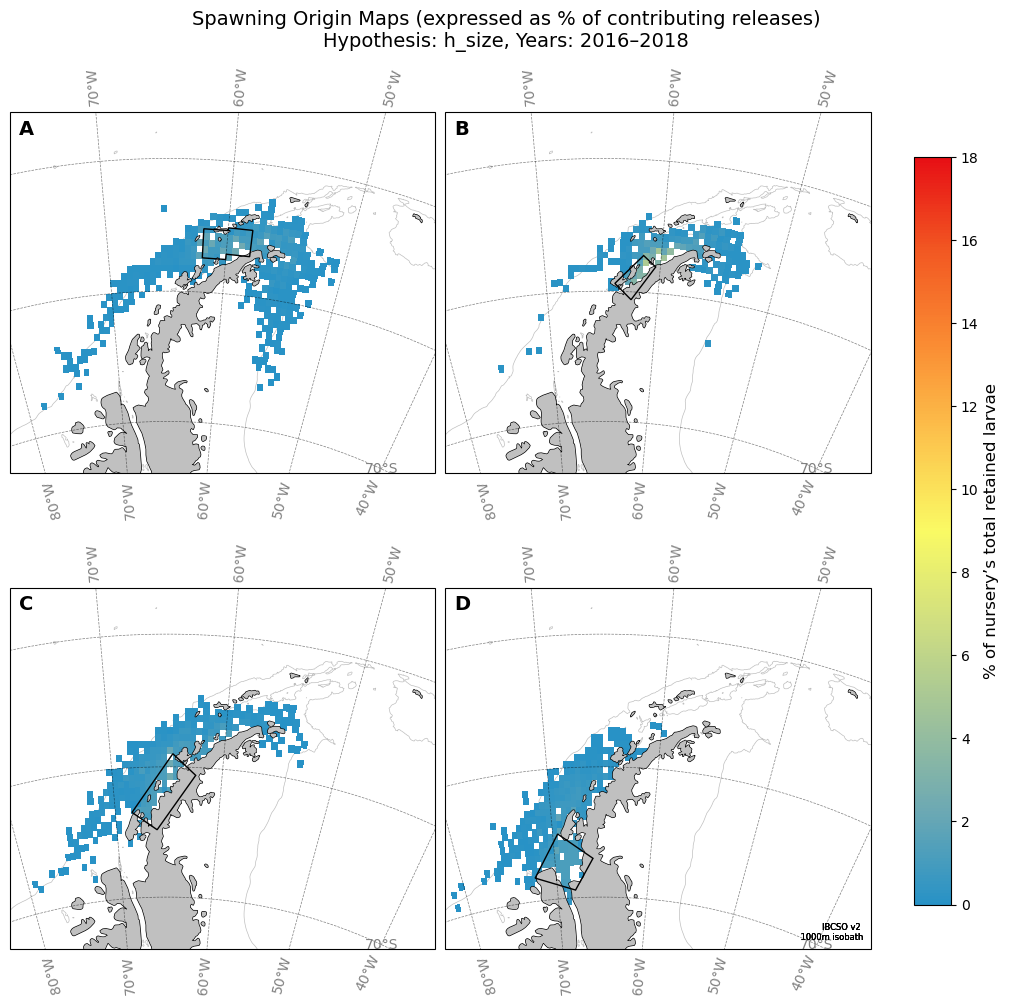

,embryo_size,nursery,total_particles,max_bin,top_5_sum,entropy,nonzero_bins
0,640,BS,2500,0.0236,0.1120,5.111,316
1,640,GERL,897,0.0524,0.2207,4.230,144
2,640,GP,2686,0.0246,0.0975,5.009,256
3,640,MB2,2879,0.0188,0.0806,5.089,251


In [25]:
# Setup
nurseries = ['BS', 'GERL', 'GP', 'MB2']
hypothesis = 'h_size'
years = [2016, 2017, 2018]
extent = [-76, -46, -71, -58]
save_path =f'figures/spawning_summary_grid_normalized_{hypothesis}_percent.pdf'

# Step 1: Analyze with your actual function
raw_hm, norm_hm = compute_spawning_heatmaps(
    df=starting_location_df,
    nurseries=nurseries,
    hypothesis=hypothesis,
    years=years,
    lat_bins=lat_bins,
    lon_bins=lon_bins
)

# Step 2: Wrap into the dict format expected by the plot function
heatmap_dict = {}
vmax = 0  # initialize to find global max
for nursery in nurseries:
    norm = norm_hm.get(nursery, None)
    if norm is not None:
        raw = raw_hm[nursery]
        heatmap_dict[nursery] = {
            'normalized': norm,
            'total_particles': int(raw.sum())
        }
        vmax = max(vmax, norm.max())  # update global max

# Step 3: Plot
plot_percent_spawning_grid(
    heatmap_dict=heatmap_dict,
    nurseries=nurseries,
    extent=extent,
    lat_bins=lat_bins,
    lon_bins=lon_bins,
    vmax=vmax,
    hypothesis=hypothesis,
    years=years,
    save_path=save_path
)

# ✅ Step 4: Get summary DataFrame
summary_df = summarize_normalized_heatmaps(
    normalized_heatmaps=norm_hm,
    raw_heatmaps=raw_hm,
    hypothesis=hypothesis
)

summary_df